In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [3]:
X

array([[-1.75045605, -7.61419286],
       [ 8.20010267,  1.26524469],
       [ 2.91992125,  6.64824048],
       ...,
       [10.03409887, -0.03076816],
       [ 7.72040199, -0.26365479],
       [ 8.91061869, -2.05168492]], shape=(1000, 2))

In [4]:
y

array([1, 0, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 1, 0, 1, 1, 2, 1, 2, 1, 0, 1,
       0, 1, 2, 2, 0, 2, 2, 2, 2, 0, 0, 1, 2, 2, 2, 1, 1, 1, 0, 0, 0, 2,
       0, 2, 0, 1, 0, 2, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0, 1, 2, 1, 2, 1, 0,
       0, 0, 2, 2, 0, 0, 2, 1, 2, 1, 2, 0, 0, 1, 1, 2, 2, 0, 2, 2, 0, 2,
       1, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1,
       1, 0, 2, 1, 0, 0, 1, 2, 2, 1, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 1, 2,
       1, 0, 0, 1, 1, 2, 2, 2, 1, 1, 1, 2, 0, 2, 1, 0, 2, 2, 1, 1, 1, 2,
       2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 1, 1, 1, 0, 2, 1, 0,
       0, 1, 2, 0, 1, 1, 2, 2, 2, 0, 2, 2, 2, 0, 0, 1, 2, 1, 0, 2, 2, 2,
       2, 0, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 1, 0, 1, 1,
       0, 1, 0, 2, 2, 1, 1, 0, 0, 1, 0, 0, 2, 1, 0, 1, 2, 0, 1, 1, 2, 0,
       1, 1, 2, 2, 2, 1, 1, 0, 0, 2, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 2, 1, 1, 1, 0, 2, 1, 2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 0,

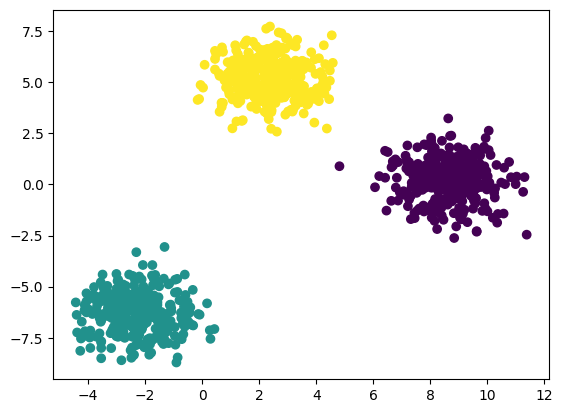

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [13]:
## Elbow Method to select the K value
wcss=[]
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[1339.9999999999989,
 397.6067783264572,
 58.58042711666723,
 52.338493028884066,
 45.70716759467055,
 38.867501654570546,
 36.90854148936146,
 32.94720334219927,
 28.557038889952217,
 24.86175902852732]

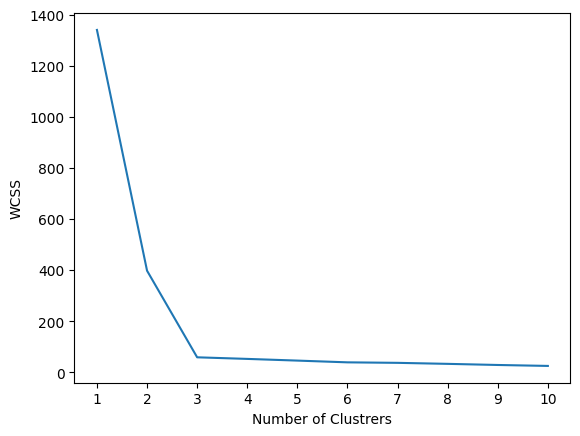

In [15]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [17]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 0, 1, 1, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 1, 0,
       1, 0, 0, 0, 2, 1, 0, 2, 2, 2, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 0, 1, 1, 1, 1, 2, 2, 0, 1, 2, 2,
       0, 1, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 2, 0, 0, 1,
       2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 2, 1, 1,
       0, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 0, 2, 1, 0, 1,
       1, 2, 1, 0, 2, 2, 1, 1, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 1, 2, 2,
       0, 0, 2, 0, 1, 2, 1, 0, 2, 0, 0, 0, 1, 0, 1, 2, 1, 1, 1, 0, 2, 0,
       0, 2, 1, 2, 1, 1, 2, 1, 0, 0, 2, 2, 1, 2, 1, 0, 1, 2, 0, 1, 1, 1,
       0, 0, 1, 0, 2, 1, 1, 0, 0, 1, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 0,
       1, 0, 0, 2, 2, 0, 2, 1, 2, 2, 0, 2, 1, 0, 1, 0, 0, 0, 2, 0, 0, 2,
       2, 1, 1, 0, 1, 1, 2, 2, 0, 1, 1, 2, 0, 2, 1, 1, 1, 2, 0, 2, 2, 1,
       2, 0, 2, 2, 1, 0, 1, 2, 1, 1, 2, 1, 2, 2, 2, 0, 1, 0, 1, 1, 0, 0,
       0, 2, 2, 0, 0, 2, 1, 1, 0, 0, 2, 2, 2, 0, 2,

In [18]:
y_pred = kmeans.predict(X_test_scaled)

In [19]:
y_pred

array([0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 0, 0, 1, 0, 1, 1, 2, 2, 1,
       0, 2, 2, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 0, 2, 2, 1, 2, 1, 0, 0, 2,
       2, 2, 1, 0, 1, 1, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 0, 2, 2, 0, 1, 1,
       0, 0, 2, 0, 0, 2, 0, 1, 2, 2, 0, 1, 1, 0, 0, 2, 0, 2, 2, 2, 2, 2,
       0, 2, 2, 0, 1, 1, 1, 2, 0, 1, 0, 0, 1, 2, 1, 1, 1, 2, 2, 1, 0, 1,
       0, 1, 1, 2, 2, 2, 0, 1, 0, 2, 2, 1, 1, 2, 2, 1, 0, 0, 0, 2, 0, 2,
       2, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1, 2, 1, 2, 1, 0, 1, 0, 0, 0, 1, 2,
       0, 1, 1, 0, 1, 0, 2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 2, 0, 1, 1, 0, 0,
       1, 2, 2, 0, 0, 1, 1, 1, 0, 0, 2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 2, 0,
       2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 1, 2, 1, 1, 1, 2, 2, 0, 2, 0, 0,
       0, 0, 2, 0, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 2, 1, 0, 1, 1, 2,
       1, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 1, 2, 2, 2, 1, 1, 1, 2, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 2, 1,
       1, 2, 2, 0, 0, 1, 2, 0, 2, 1, 1, 1, 2, 0, 2,

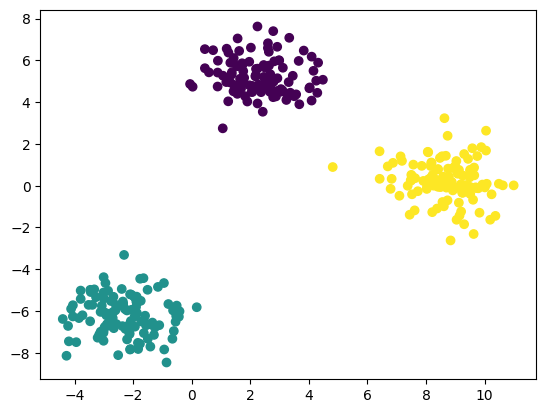

In [20]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [21]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [22]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from kneed import KneeLocator

In [24]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [25]:
kl.elbow

np.int64(3)

In [26]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [28]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [29]:
silhouette_coefficients

[np.float64(0.686616894262396),
 np.float64(0.806908788966239),
 np.float64(0.6384226122545946),
 np.float64(0.4776489994411869),
 np.float64(0.3155986171107229),
 np.float64(0.323775009120042),
 np.float64(0.33437467861697256),
 np.float64(0.3445061053799489),
 np.float64(0.32750415697449126)]

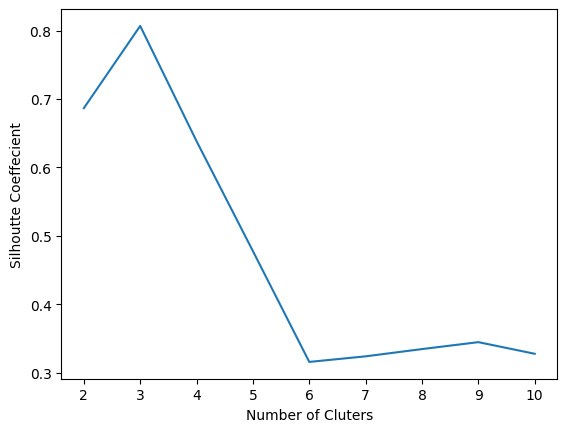

In [30]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()